You are given an m x n integer matrix grid​​​.

A rhombus sum is the sum of the elements that form the border of a regular rhombus shape in grid​​​. The rhombus must have the shape of a square rotated 45 degrees with each of the corners centered in a grid cell. Below is an image of four valid rhombus shapes with the corresponding colored cells that should be included in each rhombus sum:

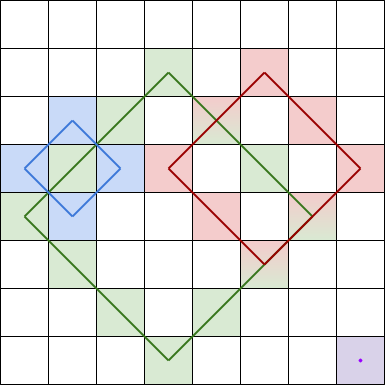

Note that the rhombus can have an area of 0, which is depicted by the purple rhombus in the bottom right corner.

Return the biggest three distinct rhombus sums in the grid in descending order. If there are less than three distinct values, return all of them.

 

Example 1:

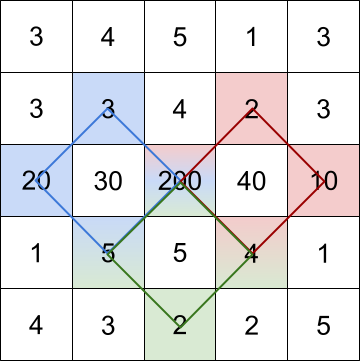

Input: grid = [[3,4,5,1,3],[3,3,4,2,3],[20,30,200,40,10],[1,5,5,4,1],[4,3,2,2,5]]
Output: [228,216,211]
Explanation: The rhombus shapes for the three biggest distinct rhombus sums are depicted above.
- Blue: 20 + 3 + 200 + 5 = 228
- Red: 200 + 2 + 10 + 4 = 216
- Green: 5 + 200 + 4 + 2 = 211

Example 2:

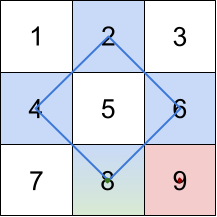

Input: grid = [[1,2,3],[4,5,6],[7,8,9]]
Output: [20,9,8]
Explanation: The rhombus shapes for the three biggest distinct rhombus sums are depicted above.
- Blue: 4 + 2 + 6 + 8 = 20
- Red: 9 (area 0 rhombus in the bottom right corner)
- Green: 8 (area 0 rhombus in the bottom middle)

Example 3:

Input: grid = [[7,7,7]]
Output: [7]
Explanation: All three possible rhombus sums are the same, so return [7].

 

Constraints:

    m == grid.length
    n == grid[i].length
    1 <= m, n <= 50
    1 <= grid[i][j] <= 105



In [ ]:
class Answer:
    def __init__(self):
        self.ans = [0, 0, 0]

    def put(self, x: int):
        _ans = self.ans

        if x > _ans[0]:
            _ans[0], _ans[1], _ans[2] = x, _ans[0], _ans[1]
        elif x != _ans[0] and x > _ans[1]:
            _ans[1], _ans[2] = x, _ans[1]
        elif x != _ans[0] and x != _ans[1] and x > _ans[2]:
            _ans[2] = x

    def get(self) -> List[int]:
        _ans = self.ans

        return [num for num in _ans if num != 0]
        
        
class Solution:
    def getBiggestThree(self, grid: List[List[int]]) -> List[int]:
        m, n = len(grid), len(grid[0])
        sum1 = [[0] * (n + 2) for _ in range(m + 1)]
        sum2 = [[0] * (n + 2) for _ in range(m + 1)]

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                sum1[i][j] = sum1[i - 1][j - 1] + grid[i - 1][j - 1]
                sum2[i][j] = sum2[i - 1][j + 1] + grid[i - 1][j - 1]

        ans = Answer()
        for i in range(m):
            for j in range(n):
                # a single cell is also a rhombus
                ans.put(grid[i][j])
                for k in range(i + 2, m, 2):
                    ux, uy = i, j
                    dx, dy = k, j
                    lx, ly = (i + k) // 2, j - (k - i) // 2
                    rx, ry = (i + k) // 2, j + (k - i) // 2

                    if ly < 0 or ry >= n:
                        break

                    ans.put(
                        (sum2[lx + 1][ly + 1] - sum2[ux][uy + 2])
                        + (sum1[rx + 1][ry + 1] - sum1[ux][uy])
                        + (sum1[dx + 1][dy + 1] - sum1[lx][ly])
                        + (sum2[dx + 1][dy + 1] - sum2[rx][ry + 2])
                        - (
                            grid[ux][uy]
                            + grid[dx][dy]
                            + grid[lx][ly]
                            + grid[rx][ry]
                        )
                    )

        return ans.get()